# 第087课 激活初始化与梯度传播

先做预测，再运行；二阶矩不等于方差，真实小样本记忆不等于泛化。全部运行离线。

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
from pathlib import Path
import json
import numpy as np
import experiment as ex
from IPython.display import display, Image
x, y, metadata = ex.load_wine()
print("真实数据形状", x.shape, "类别数量", np.bincount(y).tolist())
print("原始行号", metadata["row_ids"])
print("标准化每列均值最大绝对误差", float(np.max(np.abs(x.mean(0)))))

真实数据形状 (30, 13) 类别数量 [10, 10, 10]
原始行号 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]
标准化每列均值最大绝对误差 8.844776762847081e-16


## 先验证统计量
四点ReLU输出的均值为1，二阶矩2.5，方差1.5。分别计算，不把名字相近的量混在一起。

In [2]:
z = np.array([-3., -1., 1., 3.])
a = ex.activate(z, "relu")
print("input", z.tolist(), "ReLU", a.tolist())
print("moments", ex.moments(a))
for mode in ["xavier", "he"]:
    std = ex.weight_std(64, 32, mode)
    print(mode, "64→32 std", std, "variance", std**2)
print("24层等宽Xavier/ReLU理论二阶矩", 2.0**(-24))

input [-3.0, -1.0, 1.0, 3.0] ReLU [0.0, 0.0, 1.0, 3.0]
moments {'mean': 1.0, 'variance': 1.5, 'second_moment': 2.5, 'rms': 1.5811388300841898, 'zero_fraction': 0.5}
xavier 64→32 std 0.14433756729740643 variance 0.020833333333333332
he 64→32 std 0.1767766952966369 variance 0.03125000000000001
24层等宽Xavier/ReLU理论二阶矩 5.960464477539063e-08


## 真正执行完整实验
72组传播、18组残差、9组真实小样本训练。三个种子全部保留，small没有因训练失败被剔除。

In [3]:
result = ex.run()
out = Path("outputs")
out.mkdir(exist_ok=True)
(out / "notebook-result.json").write_text(json.dumps(result, ensure_ascii=False, indent=2, allow_nan=False))
print("传播/残差/训练组数", len(result["propagation"]), len(result["residual"]), len(result["training"]))
for mode in ["small", "xavier", "he", "large"]:
    group = [p for p in result["propagation"] if p["depth"] == 24 and p["activation"] == "relu" and p["initialization"] == mode]
    print(mode, "末层二阶矩中位数", np.median([p["final_second_moment"] for p in group]), "梯度RMS比中位数", np.median([p["gradient_rms_ratio"] for p in group]))

传播/残差/训练组数 72 18 9
small 末层二阶矩中位数 1.318455045960084e-60 梯度RMS比中位数 1.8218604527062876e-30
xavier 末层二阶矩中位数 5.912156899792544e-08 梯度RMS比中位数 0.00038579395718546484
he 末层二阶矩中位数 0.9918953333371017 梯度RMS比中位数 1.5802120486316669
large 末层二阶矩中位数 1.3184550459600827e+36 梯度RMS比中位数 1.821860452706286e+18


## 训练验收用两个指标
准确率需要100%，且平均交叉熵小于0.02。small的硬准确率可以高，但概率仍近均匀。

In [4]:
for row in result["training"]:
    print(row["seed"], row["initialization"], "CE", row["final_loss"], "accuracy", row["final_accuracy"], "pass", row["memorization_pass"])
print("均匀三分类CE", np.log(3.0))
print("所有He均通过", result["all_he_memorization_pass"])

8701 small CE 1.09861226525207 accuracy 0.8333333333333334 pass False
8701 xavier CE 0.0005164602344889966 accuracy 1.0 pass True
8701 he CE 0.00013720917791998415 accuracy 1.0 pass True
8702 small CE 1.0986122703256078 accuracy 0.9333333333333333 pass False
8702 xavier CE 0.00020991547459663196 accuracy 1.0 pass True
8702 he CE 0.00011855926136259057 accuracy 1.0 pass True
8703 small CE 1.0986122772663658 accuracy 0.7 pass False
8703 xavier CE 0.00022242785409739278 accuracy 1.0 pass True
8703 he CE 0.00015164936126236064 accuracy 1.0 pass True
均匀三分类CE 1.0986122886681098
所有He均通过 True


## 用真正unittest核对反向传播
包括激活、输入VJP、分类器全部参数和残差VJP的中心有限差分。不使用可能被-O删除的裸assert。

In [5]:
import unittest
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromTestCase(test_experiment.InitializationTests)
test_result = unittest.TextTestRunner(verbosity=1).run(suite)
print("tests", test_result.testsRun, "success", test_result.wasSuccessful())
if not test_result.wasSuccessful():
    raise RuntimeError("Gradient or training verification failed")

tests 14 success True


..............
----------------------------------------------------------------------
Ran 14 tests in 0.270s

OK


## 原创图1：理论曲线与二阶矩
重画四幅图，图1右下角的均值、二阶矩和方差刻意不同。

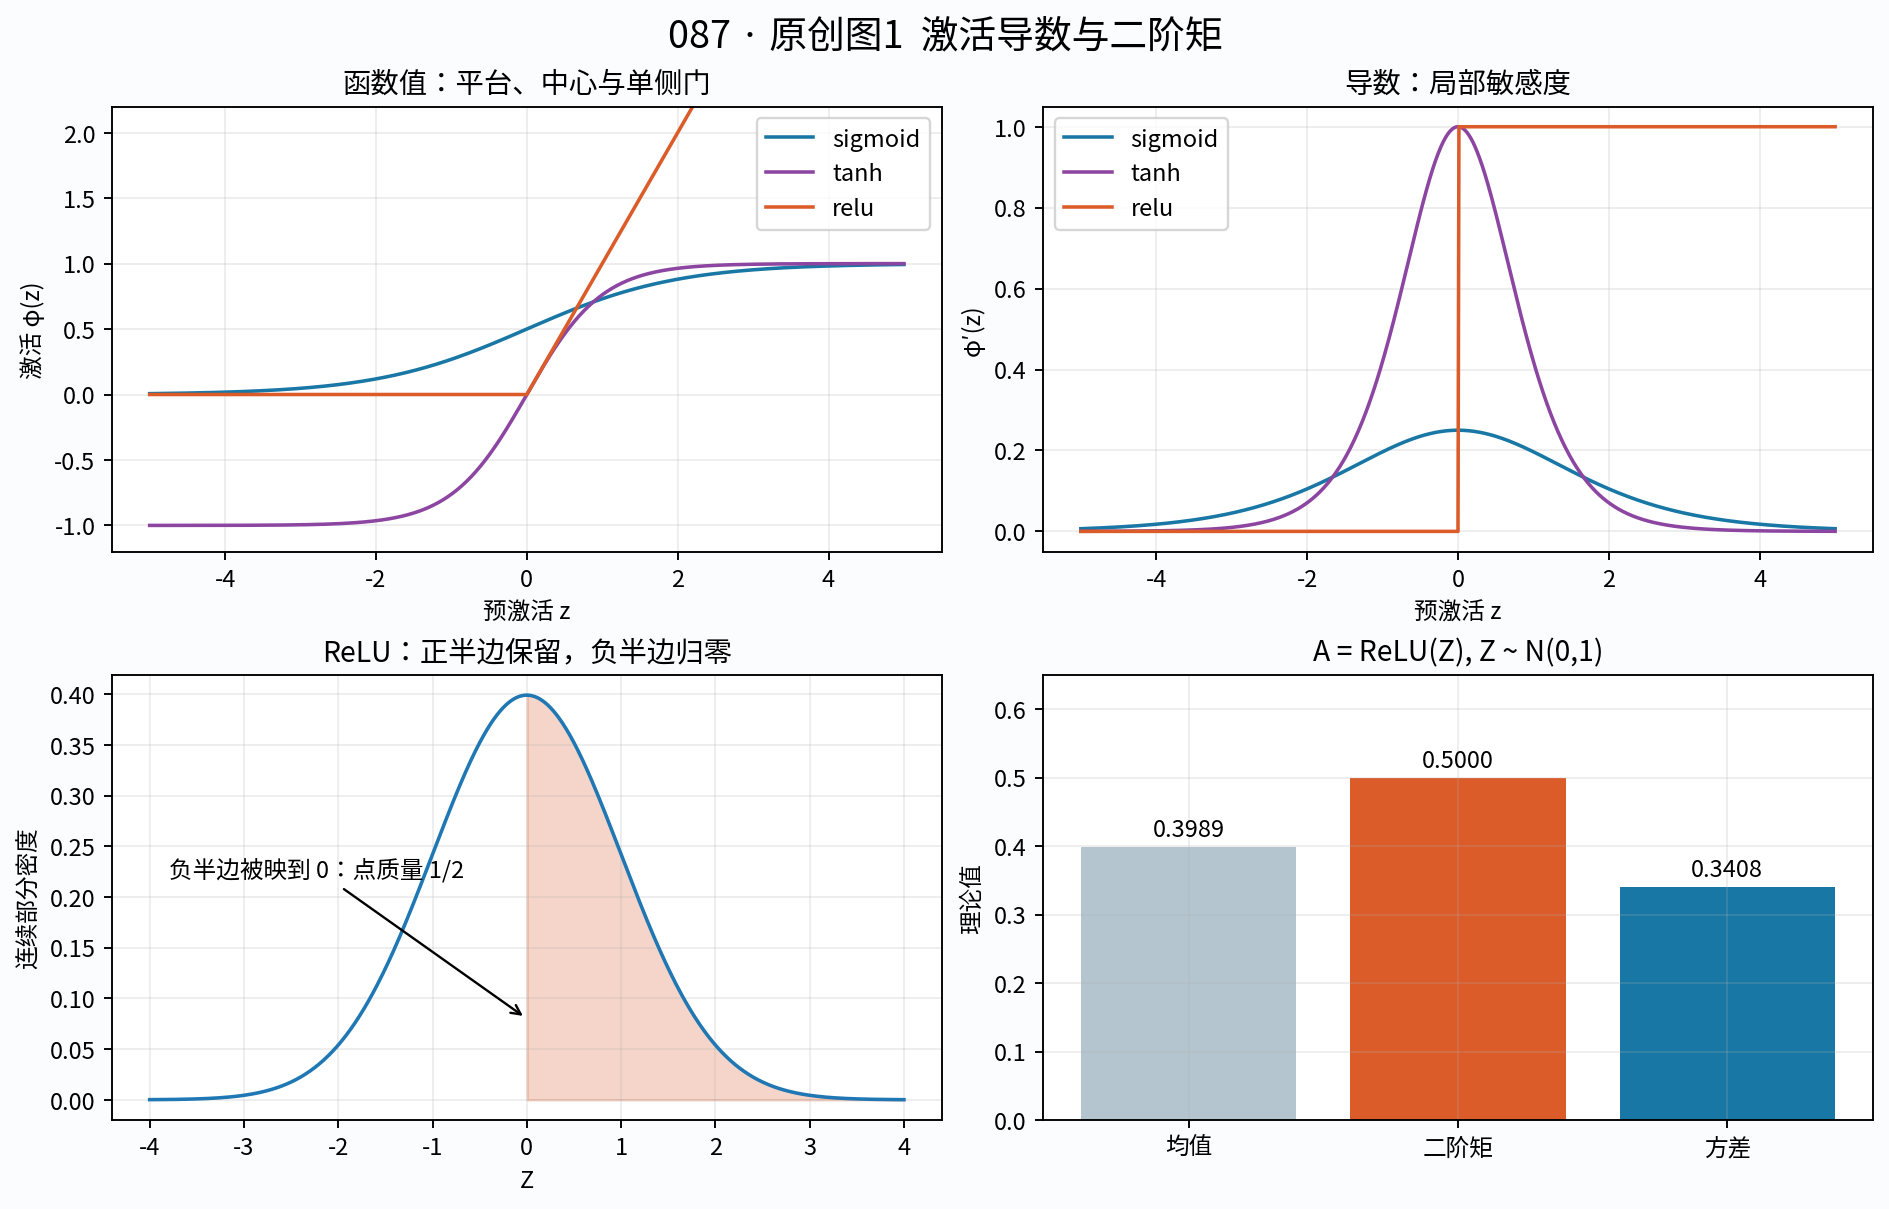

In [6]:
import plots
fig_dir = Path("outputs/notebook-figures")
plots.draw(fig_dir, result)
display(Image(filename=str(fig_dir / "01_activation_moments.png")))

## 原创图2：尺度跨越多个数量级
线为三个种子中位数，阴影是最小–最大，不是置信区间。逐层横轴由输入指向输出。

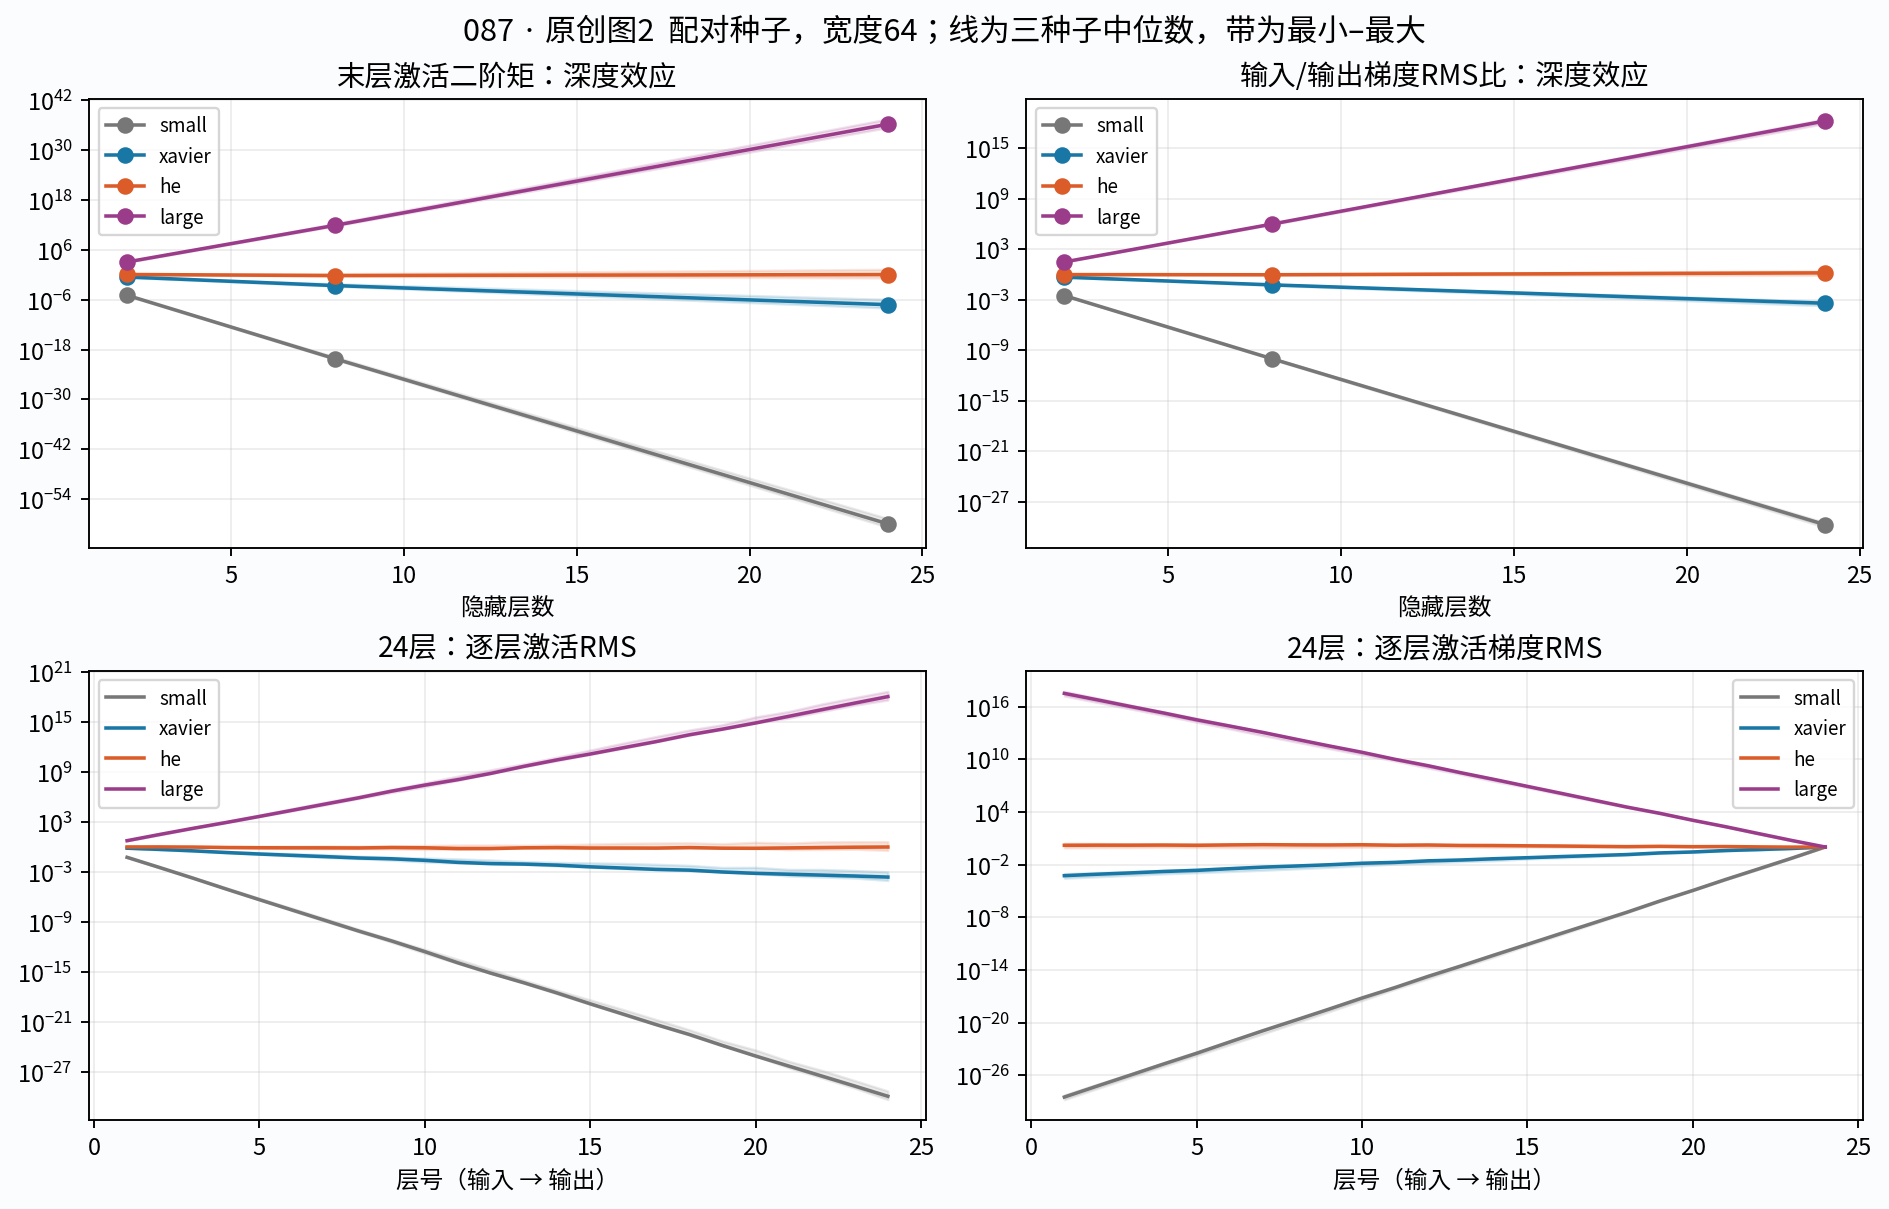

In [7]:
display(Image(filename=str(fig_dir / "02_depth_propagation.png")))

## 原创图3：非零分布与零点质量
横轴是log10绝对值；激活零值比例另标。相同种子的正缩放ReLU网络具有相同门控模式。

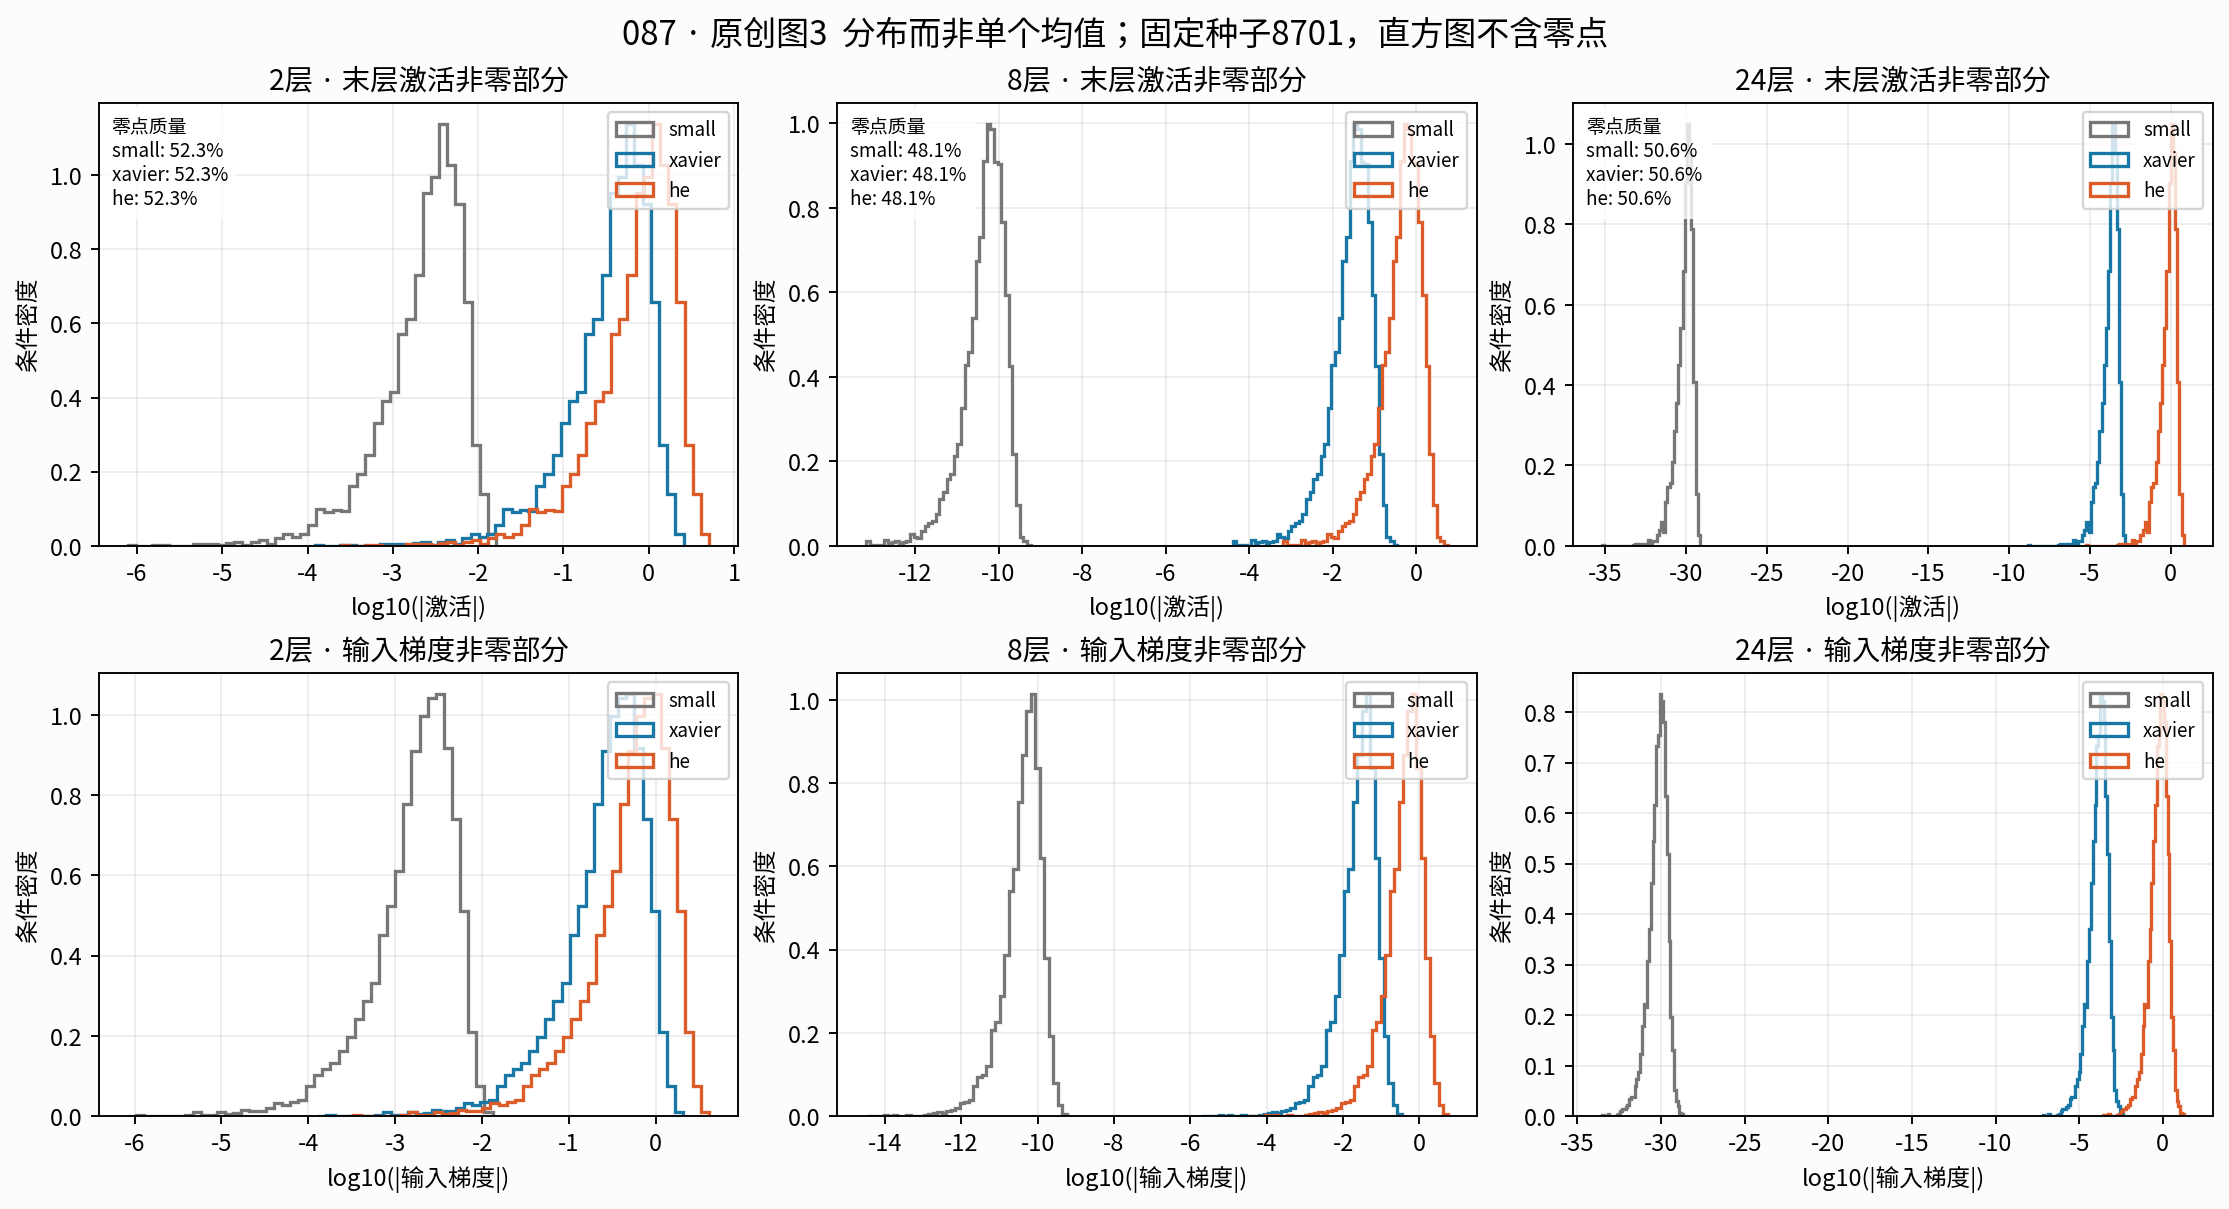

In [8]:
display(Image(filename=str(fig_dir / "03_distributions.png")))

## 原创图4：训练成功与残差边界
上半是真实Wine训练，下半是独立简化残差探针。输入、结构和任务不同，不混称同一实验。

24块残差：
{'depth': 24, 'seed': 8701, 'branch_scale': 1.0, 'final_second_moment': 18.174090396333167, 'gradient_rms_ratio': 10.570883558763319}
{'depth': 24, 'seed': 8701, 'branch_scale': np.float64(0.20412414523193154), 'final_second_moment': 1.464238214405629, 'gradient_rms_ratio': 1.2415615548019614}
分支F=-h时一块导数 0 分支F=h时24块导数 16777216


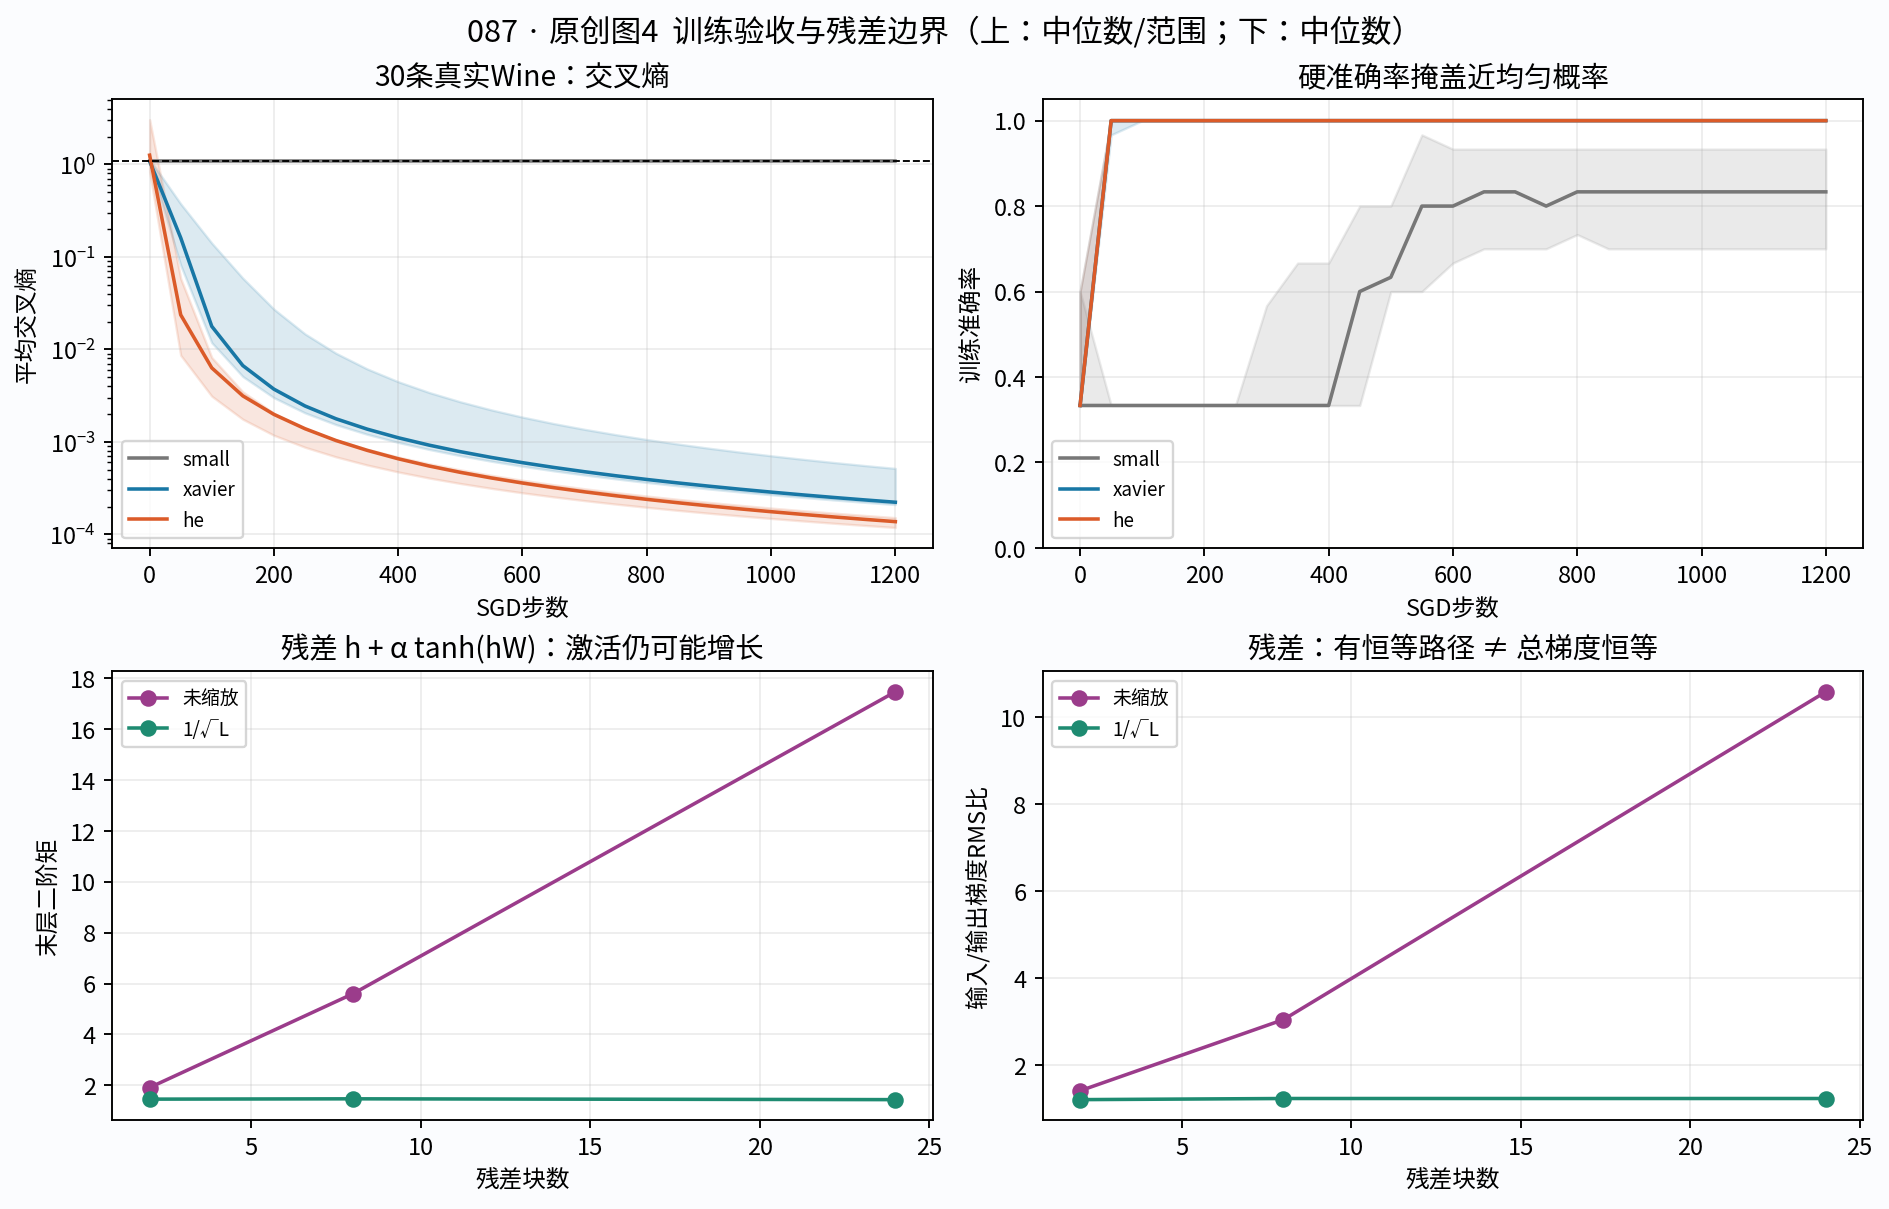

In [9]:
display(Image(filename=str(fig_dir / "04_training_residual.png")))
print("24块残差：")
for row in result["residual"]:
    if row["depth"] == 24 and row["seed"] == 8701:
        print(row)
print("分支F=-h时一块导数", 1 + (-1), "分支F=h时24块导数", 2**24)

## 结论
He与Xavier都在当前六层网络和预算下通过30条真实记录的记忆验收；small没有通过。传播式解释平均尺度，不保证全部雅可比方向。这里没有独立测试集，不作泛化结论。详见lecture.md、lab.md与answers.md。